# Dependencies

In [1]:
import os
import pandas as pd
import numpy as np
import pickle as pkl
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict, OrderedDict
import glob
import weylchamber as wc
from sb3_contrib import TRPO

from rlquantopt.rl_envs.zc_qpee import ZCQPEE
from rlquantopt.utils.rl_utils import get_pulse_data

In [2]:
%matplotlib widget

In [3]:
save_suffix = ''
fid_thresh = 0.99
max_t = 15.0
par_dir = '/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO'
interesting_steps = defaultdict(list)
# pulse_file = os.path.join(par_dir, 'results/no_term/rl_model_12566528_steps_ZCQPEE_pl-1000_T-50ns_delta_mode_ep0_no_term.csv')
verbose = 2

### Get interesting exp names

In [ ]:
exp_names = ['05-12-24_201634', 
             '14-01-25_112549', 
             '14-01-25_112615', 
             '14-01-25_112640', 
             '20-01-25_153052']
interesting_steps.update({'05-12-24_201634': [12566528],
                     '14-01-25_112549': [8470528],
                     '14-01-25_112615': [10616832],
                     '14-01-25_112640': [9338880],
                     '20-01-25_153052': [2801664]
                    })

### Get all exp names

In [4]:
exp_names = []
for exp_name in os.listdir(par_dir):
    if 'scaling' in exp_name:
        continue
    exp_names.append(exp_name)

In [5]:
{en:len(glob.glob(os.path.join(par_dir, exp_names[i], 'rl_model*'))) for i, en in enumerate(exp_names)}

{'05-12-24_123444': 200,
 '23-01-25_113016': 906,
 '23-01-25_112953': 935,
 '24-01-25_021101': 1651,
 '20-01-25_153052': 733,
 '24-01-25_021037': 1631,
 '05-12-24_155044': 249,
 '14-01-25_112549': 675,
 '25-01-25_014636': 963,
 '14-01-25_112640': 667,
 '05-12-24_182709': 213,
 '23-01-25_113528': 910,
 '23-01-25_113537': 933,
 '24-01-25_012508': 1690,
 '04-12-24_111430': 1348,
 '24-01-25_012522': 1673,
 '04-12-24_104833': 1272,
 '25-01-25_014611': 946,
 '23-01-25_113504': 911,
 '05-12-24_201634': 1622,
 '23-01-25_113022': 958,
 '06-12-24_013238': 1425,
 '24-01-25_012531': 1710,
 '05-12-24_162013': 167,
 '14-01-25_112615': 674,
 '05-12-24_151746': 348,
 '24-01-25_021139': 1654,
 '06-12-24_013654': 1101}

# Use pulse from CSV

## Load pulse

In [ ]:
tlist, amps = get_pulse_data(pulse_file)
pulse_dir = os.path.dirname(pulse_file)

if save_dir == '':
    save_dir = pulse_dir

if env_yml_dir == '':
    env_yml_dir = pulse_dir
elif env_yml_dir.startswith('../'):
    env_yml_dir = os.path.join(pulse_dir, env_yml_dir)
    env_yml_dir = os.path.abspath(env_yml_dir)

env_yml_path = None
for item in os.listdir(env_yml_dir):
    if item.endswith('.yml') or item.endswith('.yaml'):
        env_yml_path = os.path.join(env_yml_dir, item)
        break
if env_yml_path is None:
    raise Exception('No ZCQPEE environment configuration was found')

env = ZCQPEE.from_yaml(env_yml_path)
env.DUMP_INFO = True
print(repr(env))

res_save_dir = os.path.join(save_dir, 'results')
os.makedirs(res_save_dir, exist_ok=True)

In [ ]:
amps_diff = np.diff(amps, prepend=0)
len(amps_diff)

## Run pulse through ZCQPEE

In [ ]:
name = os.path.splitext(os.path.basename(pulse_file))[0]
save_name = f"{name}_{str(env)}_ep0"
save_name += save_suffix

obs = env.reset()[0]
term = False
trunc = False
idx = 0
rews = []
if verbose >= 0:
    pbar= tqdm(total=env.pulse_length)
prev_amp = 0.
pulse = [prev_amp]
lstm_states = None
info = None
realised_gates = []
amps_diff = np.diff(amps, prepend=0)

# while not (term or trunc):
while not term:
    _idx = idx * env.N_TIME_STEPS

    if env.delta_mode:
        a = amps_diff[_idx: _idx + env.N_TIME_STEPS]
    else:
        a = amps[_idx: _idx + env.N_TIME_STEPS]
    a = env.norm_action(a)
    idx += 1

    if len(a) < env.N_TIME_STEPS:
        break

    obs, r, term, trunc, info = env.step(a, can_early_term=False)

    realised_gates.append(info['realised_gate'])

    a_trans = env.transform_action(a)
    a_denorm = env.denorm_action(a_trans).reshape(env.N_TIME_STEPS)
    if env.delta_mode:
        amp_abs_denorm = prev_amp + np.cumsum(a_denorm)
    else:
        amp_abs_denorm = a_denorm
    prev_amp = amp_abs_denorm[-1]
    pulse.extend(amp_abs_denorm)

    rews.append(r)
    if verbose >= 0:
        pbar.update(env.N_TIME_STEPS)

    if idx * env.dt >= max_t:
        break

In [ ]:
# Prepare time-axis and pulse amplitude data for plotting
infidelities = 1 - np.array(env.fidelities)

n_steps_coarse = len(infidelities)
tlist_coarse = np.arange(n_steps_coarse) * env.dt * env.N_TIME_STEPS

n_steps_fine = len(pulse)
tlist_fine = np.arange(n_steps_fine) * env.dt

idx_best_coarse = np.argmax(rews)
t_best = tlist_coarse[idx_best_coarse]
idx_best_fine = np.argmin(np.abs(np.subtract(tlist_fine, t_best)))

print(f"n_steps_coarse={n_steps_coarse}, idx_best_coarse={idx_best_coarse}, idx_best_fine={idx_best_fine}")

# Use trained agent models

## Methods

In [6]:
def get_model_zip_stepnb(mz):
    return int(mz.split('_')[-2])

def get_model_list(exp_dir, every=1, steps=None):
    if steps is None:
        steps = []
    mz_list = glob.glob(os.path.join(exp_dir, 'rl_model_*.zip'))
    mz_list = sorted(mz_list, key=lambda x: int(x.split('_')[-2]))
    mz_list = [mz for i, mz in enumerate(mz_list) if (i % every == 0) or (get_model_zip_stepnb(mz) in steps)]
    return mz_list

def get_env(exp_dir):
    yml_path = ZCQPEE.find_yaml_in_dir(exp_dir)
    if yml_path is None:
        raise Exception('No ZCQPEE environment configuration was found')
    env_ = ZCQPEE.from_yaml(yml_path)
    env_.DUMP_INFO = True
    return env_

def star_line(nb=160):
    print('*'.join(['']*nb))

## Generate pulses

In [7]:
skip_every = 1

for exp_name in exp_names:
    exp_dir = os.path.join(par_dir, exp_name)
    results_path = os.path.join(exp_dir, f'eval_data_skip_every-{skip_every}.pkl')

    if os.path.exists(results_path):
        print(f'Results for "{exp_name}" skip_every={skip_every} already saved in "{results_path}"')
        star_line()
        continue

    print(f'Working on "{exp_name}"...')

    env = get_env(exp_dir)
    model_zips = get_model_list(exp_dir=exp_dir, every=skip_every, steps=interesting_steps[exp_name])

    realised_gates = defaultdict(list)
    step_states = defaultdict(list)
    pulse = OrderedDict()
    rews = defaultdict(list)
    infidelities = OrderedDict()
    concurrences = OrderedDict()
    unitarities = OrderedDict()

    pbar= tqdm(total=len(model_zips))

    for i, model_zip in enumerate(model_zips):
        name = os.path.splitext(os.path.basename(model_zip))[0]
        model_dir = os.path.dirname(model_zip)

        model = TRPO.load(model_zip)

        obs = env.reset()[0]
        term = False
        trunc = False
        idx = 0
        prev_amp = 0.
        pulse[model_zip] = [prev_amp]
        info = None

        # while not (term or trunc):
        while not term:
            a = model.predict(obs, deterministic=True)[0]
            obs, r, term, trunc, info = env.step(a, can_early_term=False)

            # Save intra-episode data
            realised_gates[model_zip].append(info['realised_gate'])
            step_states[model_zip].append(info['step_states'])
            rews[model_zip].append(r)

            # Accumulate denormalised pulse amplitudes
            a_trans = env.transform_action(a)
            a_denorm = env.denorm_action(a_trans).reshape(env.N_TIME_STEPS)
            if env.delta_mode:
                amp_abs_denorm = prev_amp + np.cumsum(a_denorm)
            else:
                amp_abs_denorm = a_denorm
            prev_amp = amp_abs_denorm[-1]
            pulse[model_zip].extend(amp_abs_denorm)


            idx += env.N_TIME_STEPS
            if idx * env.dt >= max_t:
                break

        pbar.update(1)

        # Save episode reward metrics
        infidelities[model_zip] = 1 - np.array(env.fidelities)
        concurrences[model_zip] = np.array(env.concurrences)
        unitarities[model_zip] = np.array(env.unitarities)

    # Save experiment results
    exp_results = dict(pulse=pulse,
                       realised_gates=realised_gates,
                       step_states=step_states,
                       rews=rews,
                       infidelities=infidelities,
                       concurrences=concurrences,
                       unitarities=unitarities)

    with open(results_path, 'wb') as f:
        pkl.dump(exp_results, f)
        print(f'Saved experiment results to: {results_path}')

    star_line()

Results for "05-12-24_123444" skip_every=1 already saved in "/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/05-12-24_123444/eval_data_skip_every-1.pkl"
***************************************************************************************************************************************************************
Results for "23-01-25_113016" skip_every=1 already saved in "/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/23-01-25_113016/eval_data_skip_every-1.pkl"
***************************************************************************************************************************************************************
Results for "23-01-25_112953" skip_every=1 already saved in "/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/23-01-25_112953/eval_data_skip_every-1.pkl"
**************************************************************************************************

  0%|          | 0/1014 [00:00<?, ?it/s]

/home/leander/miniconda3/envs/qvaqt/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Saved experiment results to: /home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/25-01-25_014636/eval_data_skip_every-1.pkl
***************************************************************************************************************************************************************
Results for "14-01-25_112640" skip_every=1 already saved in "/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/14-01-25_112640/eval_data_skip_every-1.pkl"
***************************************************************************************************************************************************************
Results for "05-12-24_182709" skip_every=1 already saved in "/home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/05-12-24_182709/eval_data_skip_every-1.pkl"
***********************************************************************************************************************************

# Load generated data

In [5]:
eval_data_fn = 'eval_data_skip_every-1.pkl'
exp_data = {}
for exp_name in exp_names:
    # if '2016' not in exp_name:
    #     continue
    exp_dir = os.path.join(par_dir, exp_name)
    with open(os.path.join(exp_dir, eval_data_fn), 'rb') as f:
        data = pkl.load(f)
    exp_data[exp_name] = data

In [6]:
print(list(exp_data.keys()))

['05-12-24_201634', '14-01-25_112549', '14-01-25_112615', '14-01-25_112640', '20-01-25_153052']


# Plotting

## Reward metrics plots

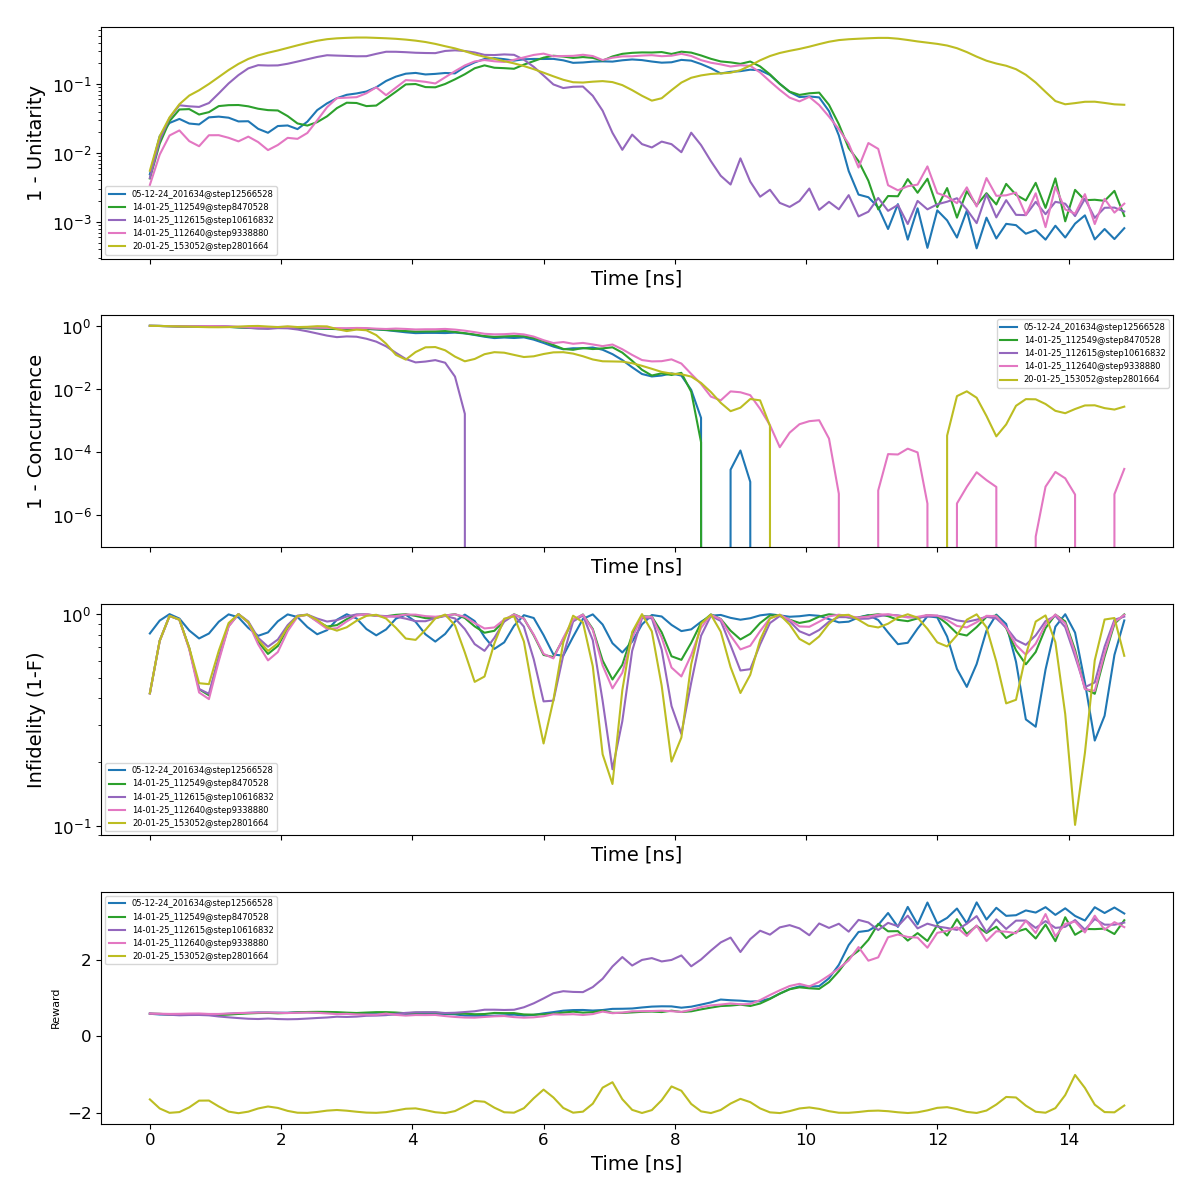

In [15]:
fig, axs = plt.subplots(4, sharex=True, figsize=(12, 12))
axis_fs = 14
axs[0].set_ylabel('1 - Unitarity', fontsize=axis_fs)
axs[0].set_yscale('log')
axs[1].set_ylabel('1 - Concurrence', fontsize=axis_fs)
axs[1].set_yscale('log')
axs[2].set_ylabel('Infidelity (1-F)', fontsize=axis_fs)
axs[2].set_yscale('log')
axs[3].set_ylabel('Reward', fontsize=8)

cmap = mpl.colormaps.get_cmap('tab10')

for i, exp_name in enumerate(exp_data):
    env = get_env(os.path.join(par_dir, exp_name))

    best_step = interesting_steps[exp_name][0]

    model_zip = None
    for mz in exp_data[exp_name]['rews']:
        if get_model_zip_stepnb(mz) == best_step:
            model_zip = mz
            break

    infidelities = exp_data[exp_name]['infidelities'][model_zip]
    concurrences = exp_data[exp_name]['concurrences'][model_zip]
    unitarities = exp_data[exp_name]['unitarities'][model_zip]
    rewards = exp_data[exp_name]['rews'][model_zip]

    
    tlist_coarse = np.arange(len(rewards)) * env.dt * env.N_TIME_STEPS
    
    max_rew_t = tlist_coarse[np.argmax(rewards)]

    lbl = f'{exp_name}@step{best_step}'

    c = cmap(i/len(exp_data))
    
    ax = axs[0]
    ax.plot(tlist_coarse, 1-unitarities, label=lbl, c=c)

    ax = axs[1]
    ax.plot(tlist_coarse, 1-concurrences, label=lbl, c=c)

    ax = axs[2]
    ax.plot(tlist_coarse, infidelities, label=lbl, c=c)
    
    ax = axs[3]
    ax.plot(tlist_coarse, rewards, label=lbl, c=c)

for ax in axs:
    # ax.axvline(max_rew_t, color='g', ls=':', lw=1, label='Max reward')
    ax.set_xlabel('Time [ns]', fontsize=axis_fs)
    ax.legend(loc='best', prop={'size': 6})
    ax.tick_params(axis='both', which='major', labelsize=axis_fs-2)
    ax.tick_params(axis='both', which='minor', labelsize=axis_fs-4)
    
fig.tight_layout()
plt.show()

## Weylchamber plot

### Load best realised gate only from all zips

In [31]:
c_label = 'Training Steps'
c1_dd, c2_dd, c3_dd = defaultdict(list), defaultdict(list), defaultdict(list)
t_dd = defaultdict(list)
for exp_name in exp_names:
    # c1, c2, c3, t = [], [], [], []
    realised_gates = exp_data[exp_name]['realised_gates']
    rews = exp_data[exp_name]['rews']
    for i, (model_zip, rg) in enumerate(realised_gates.items()):
        idx = np.argmax(rews[model_zip])
        _c1, _c2, _c3 = wc.c1c2c3(rg[idx])
        
        # Fix asymmetry in Weylchamber - 20/01/2025 MK, TA, GV, LG, MC meeting
        # if _c1 > 0.5:
        #     _c1 = 1 - _c1
            
        step_nb = get_model_zip_stepnb(model_zip)
        
        c1_dd[exp_name].append(_c1)
        c2_dd[exp_name].append(_c2)
        c3_dd[exp_name].append(_c3)
        t_dd[exp_name].append(step_nb)

In [22]:
list(c1_dd.keys())

['05-12-24_201634',
 '14-01-25_112549',
 '14-01-25_112615',
 '14-01-25_112640',
 '20-01-25_153052']

### Load last realised gate from all zips

In [49]:
c_label = 'Training Steps'
c1_dd, c2_dd, c3_dd = defaultdict(list), defaultdict(list), defaultdict(list)
t_dd = defaultdict(list)
for exp_name in exp_names:
    # c1, c2, c3, t = [], [], [], []
    realised_gates = exp_data[exp_name]['realised_gates']
    rews = exp_data[exp_name]['rews']
    for i, (model_zip, rg) in enumerate(realised_gates.items()):
        _c1, _c2, _c3 = wc.c1c2c3(rg[-1])
        
        # Fix asymmetry in Weylchamber - 20/01/2025 MK, TA, GV, LG, MC meeting
        if _c1 > 0.5:
            _c1 = 1 - _c1
            
        step_nb = get_model_zip_stepnb(model_zip)
        
        c1_dd[exp_name].append(_c1)
        c2_dd[exp_name].append(_c2)
        c3_dd[exp_name].append(_c3)
        t_dd[exp_name].append(step_nb)

### Load one model

In [40]:
c1_dd, c2_dd, c3_dd = defaultdict(list), defaultdict(list), defaultdict(list)
t_dd = defaultdict(list)

c_label = 'Time [ns]'
# exp_name = '05-12-24_201634'
for exp_name in exp_names:
    print(exp_name)
    # step = 12566528
    # exp_name = '20-01-25_153052'
    step = interesting_steps[exp_name][0]
    
    realised_gates = exp_data[exp_name]['realised_gates']
    env = get_env(os.path.join(par_dir, exp_name))
    
    for model_zip, rgs in realised_gates.items():
        cur_stepnb = get_model_zip_stepnb(model_zip)
        if cur_stepnb != step:
            continue
    
        for i, rg in enumerate(rgs):
            _c1, _c2, _c3 = wc.c1c2c3(rg)
            
            c1_dd[exp_name].append(_c1)
            c2_dd[exp_name].append(_c2)
            c3_dd[exp_name].append(_c3)
            t = (i+1)*env.dt*env.N_TIME_STEPS
            t_dd[exp_name].append(t)
        # break

05-12-24_201634
14-01-25_112549
14-01-25_112615
14-01-25_112640
20-01-25_153052


## Weylchamber package - all exps

05-12-24_201634


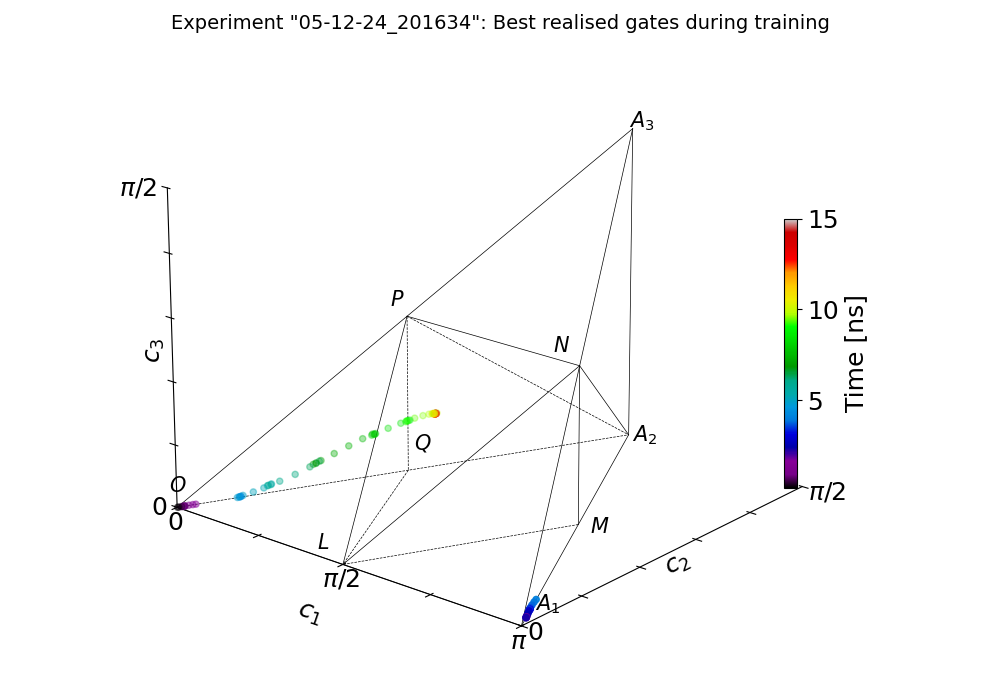

14-01-25_112549


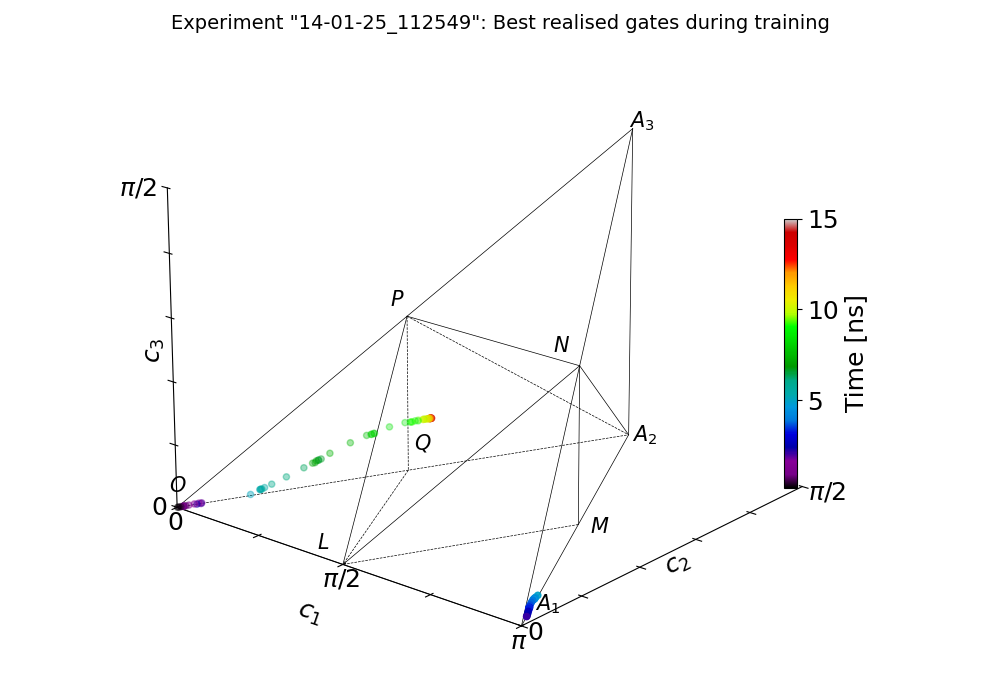

14-01-25_112615


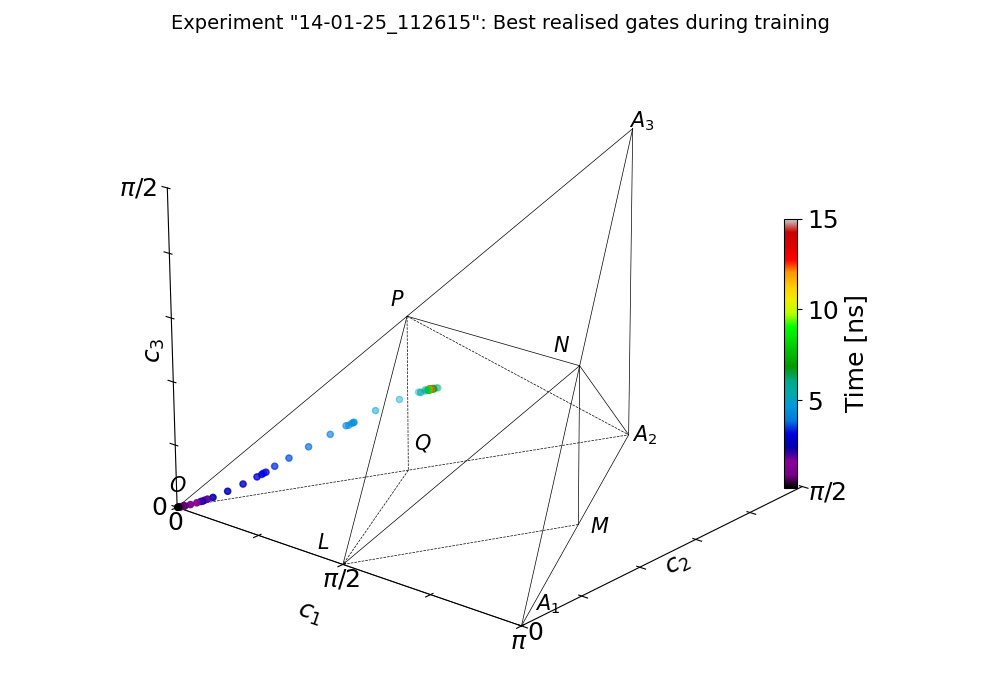

14-01-25_112640


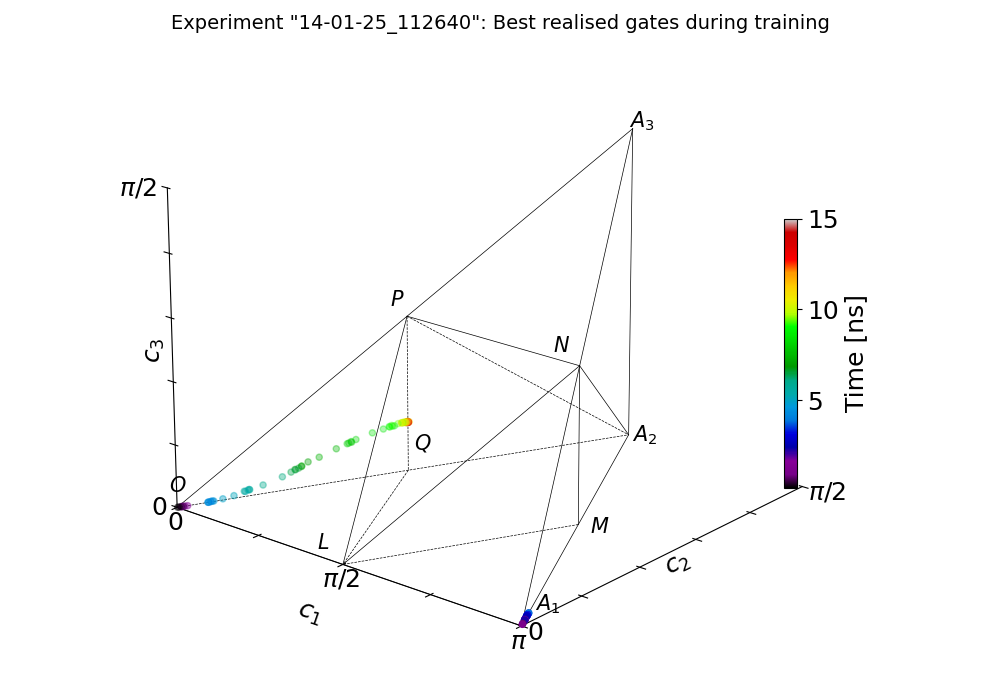

20-01-25_153052


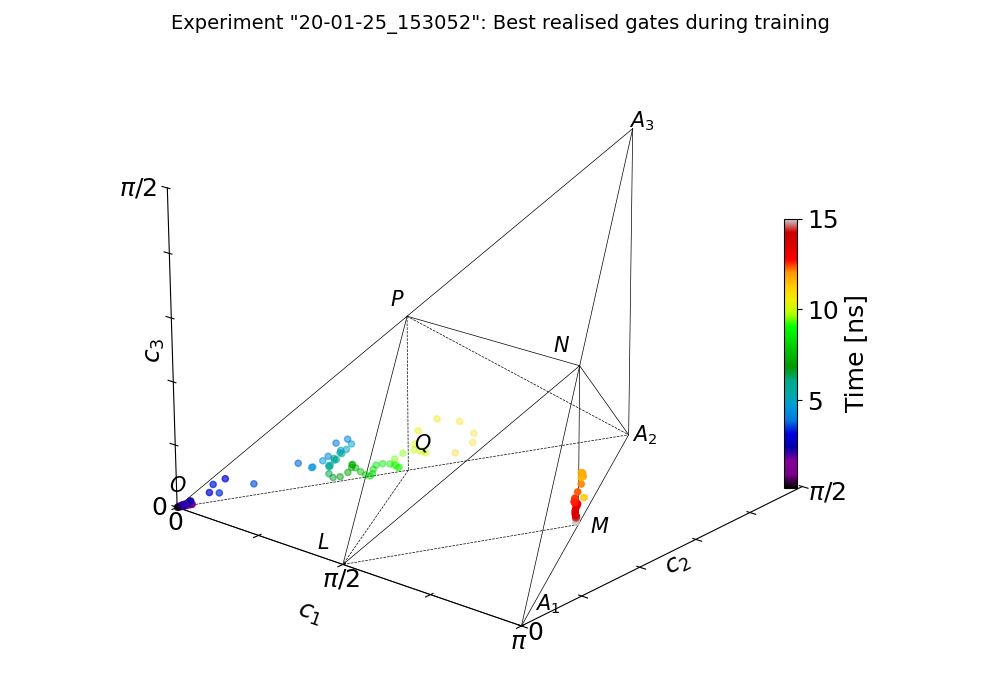

In [41]:
import matplotlib as mpl
cmap = mpl.colormaps.get_cmap('nipy_spectral')

# w = wc.WeylChamber()
# figsz = 20
# w.fig_width = figsz
# w.fig_height = figsz
# w.c1_labelpad = 7

for i, exp_name in enumerate(exp_names):
    
    print(exp_name)

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.suptitle(f'Experiment "{exp_name}": Best realised gates during training', fontsize=14)
    w = wc.WeylChamber()
    w.c1_labelpad = 7
    
    c1 = c1_dd[exp_name]
    c2 = c2_dd[exp_name]
    c3 = c3_dd[exp_name]
    t = t_dd[exp_name]
    cNorm = mpl.colors.Normalize(vmin=min(t), vmax=max(t))
    scalarMap = mpl.cm.ScalarMappable(norm=cNorm, cmap=cmap)
    w.scatter(c1, c2, c3, c=scalarMap.to_rgba(t))

    # Add a colorbar from the figure
    scatter = ax.scatter(c1,c2,c3, c=t, cmap='nipy_spectral')
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=20)
    cbar.set_label(c_label)
    scatter.remove()
    
    # Turn off all spines and labels
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_yticks([])  # Remove y-axis ticks
    
    w.plot(fig)
    plt.show()
# save_name = name+'_weylchamber.pdf'
# fig.savefig(save_name)

## Weylchamber plotly

In [13]:
import numpy as np
from plotly.subplots import make_subplots

import plotly.graph_objects as go

# Weyl chamber points
weyl_points = {
    'A1': (1, 0, 0),
    'A2': (0.5, 0.5, 0),
    'A3': (0.5, 0.5, 0.5),
    'O': (0, 0, 0),
    'L': (0.5, 0, 0),
    'M': (0.75, 0.25, 0),
    'N': (0.75, 0.25, 0.25),
    'P': (0.25, 0.25, 0.25),
    'Q': (0.25, 0.25, 0),
}

# Weyl edges
weyl_edges = [
    ('O', 'A1'),
    ('A1', 'A2'),
    ('A2', 'A3'),
    ('A3', 'A1'),
    ('A3', 'O'),
    ('O', 'A2'),
]

# Polyhedron of perfect entanglers (PE) edges
PE_edges = [
    ('L', 'N'),
    ('L', 'P'),
    ('N', 'P'),
    ('N', 'A2'),
    ('N', 'M'),
    ('M', 'L'),
    ('Q', 'L'),
    ('P', 'Q'),
    ('P', 'A2'),
]

# Extract points for easy access
def get_point(name):
    return weyl_points[name]

### All experiments together

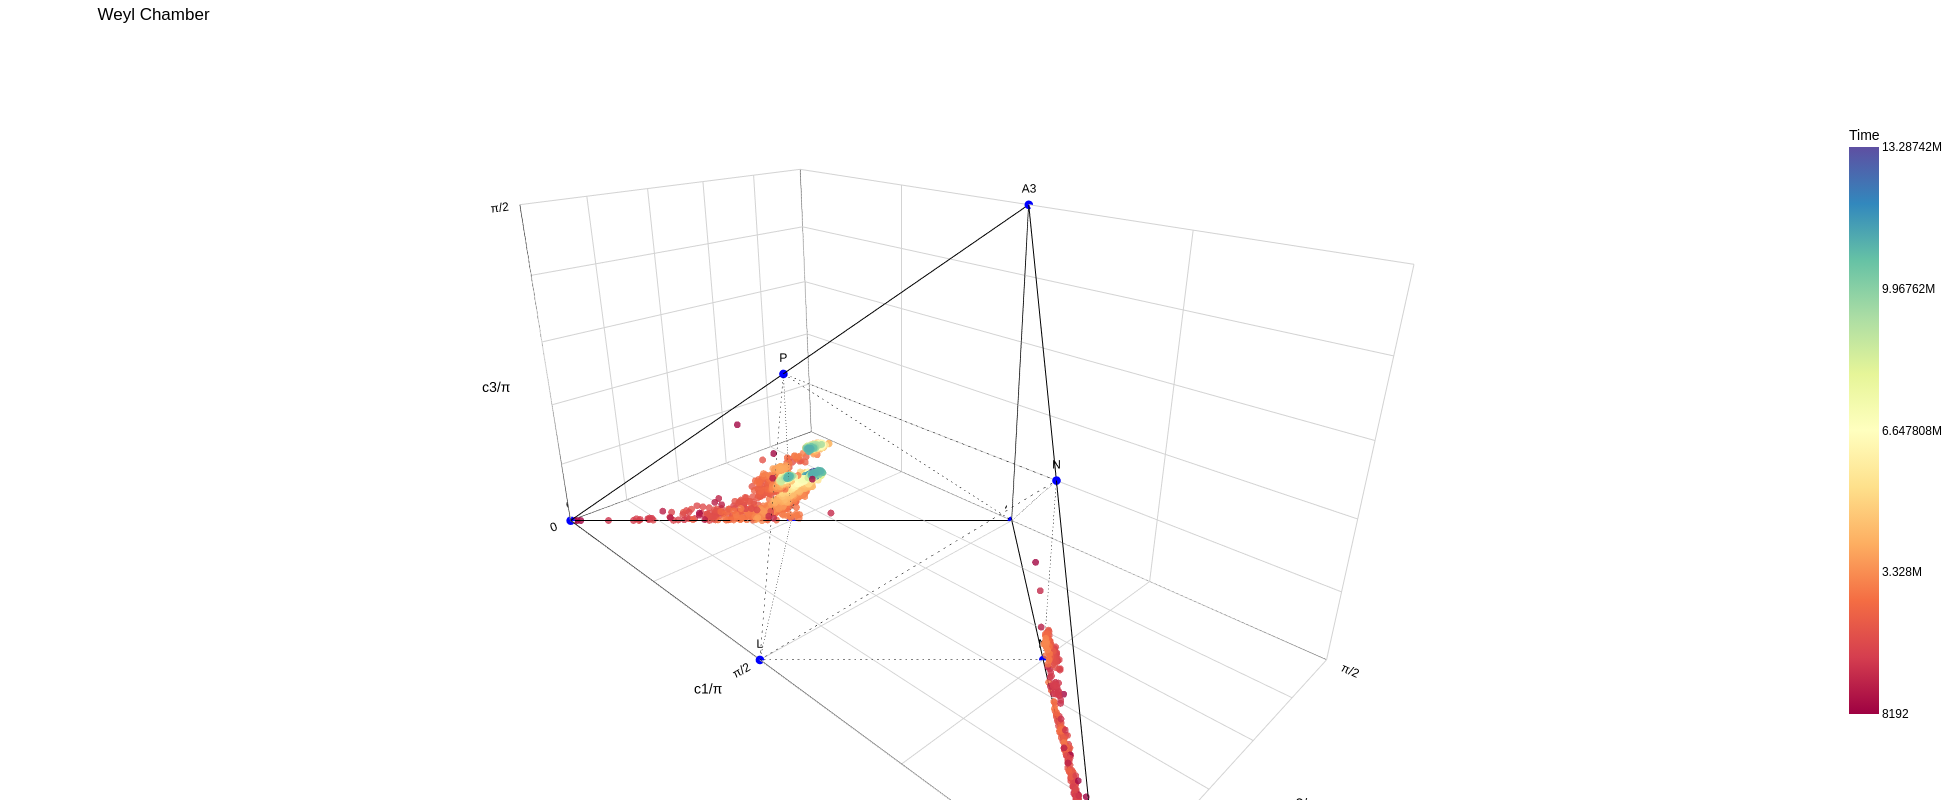

In [32]:
# Create figure
fig = go.Figure()

# Add edges for the Weyl chamber and PE polyhedron
for edges, line_style in [(weyl_edges, dict(color='black', width=2)),
                          (PE_edges, dict(color='black', dash='dash', width=1))]:
    for p1, p2 in edges:
        x, y, z = zip(*[get_point(p1), get_point(p2)])
        fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='lines', line=line_style))

# Add scatter points for Weyl chamber vertices
for name, coord in weyl_points.items():
    fig.add_trace(go.Scatter3d(
        x=[coord[0]], y=[coord[1]], z=[coord[2]],
        mode='markers+text',
        marker=dict(size=5, color='blue'),
        text=name,
        textposition='top center'
    ))

# Normalize t values for a shared color scale
t_all = np.concatenate([t_dd[exp_name] for exp_name in exp_names])  # Combine all t values
t_min, t_max = np.min(t_all), np.max(t_all)  # Get the global min and max

# Add data for experiments
for i, exp_name in enumerate(exp_names):
    fig.add_trace(go.Scatter3d(
        x=c1_dd[exp_name], y=c2_dd[exp_name], z=c3_dd[exp_name],
        mode='markers',
        marker=dict(
            size=4,
            color=t_dd[exp_name],  # Color mapped to time
            colorscale='spectral',  # Use the same colorscale
            opacity=0.8,
            cmin=t_min,  # Set global minimum
            cmax=t_max,  # Set global maximum
            colorbar=dict(
                title='Time',
                tickvals=np.linspace(t_min, t_max, 5),
                len=0.8,
            ) if i == 0 else None,  # Show colorbar only for the first trace
        ),
        name=exp_name  # Optional: Add trace name
    ))

# Set axis labels and limits
fig.update_layout(
    scene=dict(
        xaxis=dict(
            title='c1/π',
            tickvals=[0, 0.25, 0.5, 0.75, 1],
            ticktext=['0', '', 'π/2', '', 'π'],
            range=[0, 1],
            color='black',
            gridcolor='lightgray',
            zerolinecolor='black',
            backgroundcolor='white',
        ),
        yaxis=dict(
            title='c2/π',
            tickvals=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
            ticktext=['0', '', '', '', '', 'π/2'],
            range=[0, 0.5],
            color='black',
            gridcolor='lightgray',
            zerolinecolor='black',
            backgroundcolor='white',
        ),
        zaxis=dict(
            title='c3/π',
            tickvals=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
            ticktext=['0', '', '', '', '', 'π/2'],
            range=[0, 0.5],
            color='black',
            gridcolor='lightgray',
            zerolinecolor='black',
            backgroundcolor='white',
        ),
        bgcolor='white'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black'),
    margin=dict(l=0, r=0, t=40, b=0),
    title='Weyl Chamber',
    scene_camera=dict(eye=dict(x=1.25, y=-1.25, z=0.75)),  # Camera view
    width=1000,
    height=800,
    showlegend=False
)

# Show the plot
fig.show()


### Experiments separated

In [84]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# Create a 2x2 subplot layout with 3D subplots
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}],
           [{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=exp_names,  # Titles for each subplot
    vertical_spacing=0.05,
    horizontal_spacing=0.05
)

# Normalize t values for a shared color scale
t_all = np.concatenate([t_dd[exp_name] for exp_name in exp_names])  # Combine all t values
t_min, t_max = np.min(t_all), np.max(t_all)  # Get the global min and max

# Iterate over experiments and plot in separate subplots
for idx, exp_name in enumerate(exp_names):
    row, col = divmod(idx, 2)  # Compute row and column index (0-indexed)
    c1, c2, c3, t = c1_dd[exp_name], c2_dd[exp_name], c3_dd[exp_name], t_dd[exp_name]

    # Add the experiment's data
    fig.add_trace(
        go.Scatter3d(
            x=c1, y=c2, z=c3,
            mode='markers',
            marker=dict(
                size=4,
                color=t,  # Color mapped to time
                cmin=t_min,  # Use global min for color scaling
                cmax=t_max,  # Use global max for color scaling
                colorscale='spectral',
                opacity=0.8,
                colorbar=dict(  # Configure shared colorbar
                    title='Time',
                    len=0.8,  # Adjust colorbar length
                ) if idx == 0 else None,  # Show colorbar only for the first subplot
            ),
        ),
        row=row + 1, col=col + 1
    )

    # Add edges for Weyl chamber and PE polyhedron
    for edges, line_style in [(weyl_edges, dict(color='black', width=2)),
                              (PE_edges, dict(color='black', dash='dash', width=1))]:
        for p1, p2 in edges:
            x, y, z = zip(*[get_point(p1), get_point(p2)])
            fig.add_trace(
                go.Scatter3d(x=x, y=y, z=z, mode='lines', line=line_style),
                row=row + 1, col=col + 1
            )

    # Add scatter points for Weyl chamber vertices
    for name, coord in weyl_points.items():
        fig.add_trace(
            go.Scatter3d(
                x=[coord[0]], y=[coord[1]], z=[coord[2]],
                mode='markers+text',
                marker=dict(size=5, color='blue'),
                text=name,
                textposition='top center'
            ),
            row=row + 1, col=col + 1
        )

# Set a consistent layout for all subplots
fig.update_layout(
    height=700, width=1200,  # Adjust size for tight layout
    # title_text='Experiments in 3D Subplots',  # Overall title
    margin=dict(l=10, r=10, t=30, b=10),  # Tight margins
    showlegend=False,  # Disable legend for simplicity
    coloraxis_colorbar=dict(  # Shared colorbar settings
        title="Time",
        tickvals=np.linspace(t_min, t_max, 5),
        len=0.8,
        x=1.1,  # Place the colorbar outside the main plot
    ),
)

# Set axis labels and style for all subplots
for i in range(1, len(exp_names) + 1):  # Adjusting for the number of experiments
    fig['layout'][f'scene{i}'].update(
        xaxis=dict(
            title='c1/π',
            tickvals=[0, 0.25, 0.5, 0.75, 1],
            ticktext=['0', '', 'π/2', '', 'π'],
            range=[0, 1],
        ),
        yaxis=dict(
            title='c2/π',
            tickvals=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
            ticktext=['0', '', '', '', '', 'π/2'],
            range=[0, 0.5],
        ),
        zaxis=dict(
            title='c3/π',
            tickvals=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
            ticktext=['0', '', '', '', '', 'π/2'],
            range=[0, 0.5],
        ),
    )

# Display the plot
fig.show()


## Weylchamber 2D

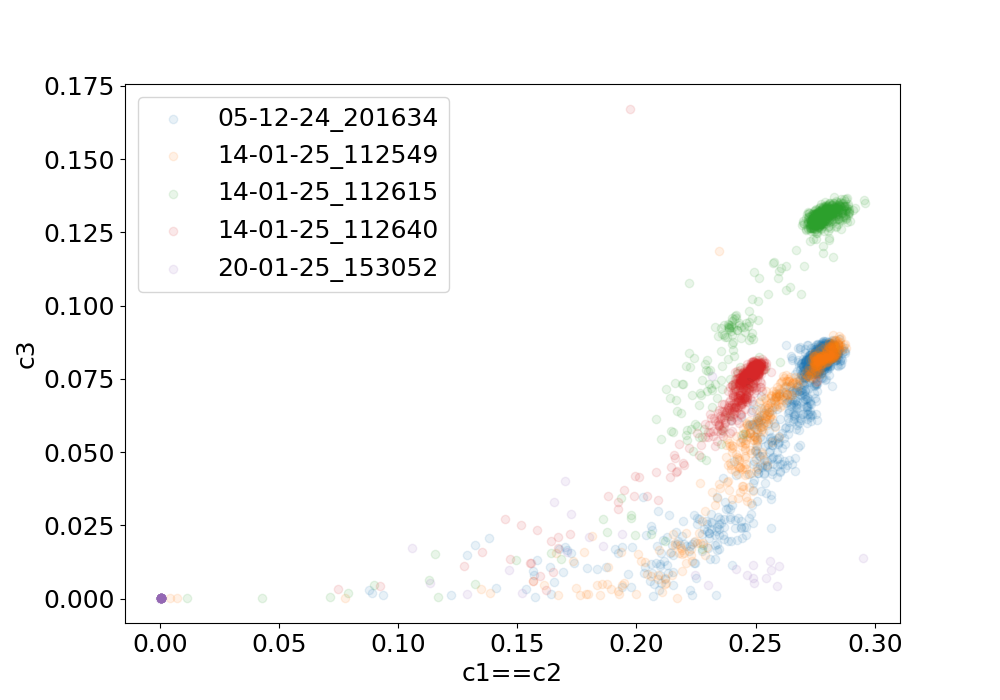

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlabel('c1==c2')
ax.set_ylabel('c3')
for exp_name in exp_names:
    c1 = c1_dd[exp_name]
    c2 = c2_dd[exp_name]
    c3 = c3_dd[exp_name]
    c = np.array([[i1, i3] for i1, i2, i3 in zip(c1, c2, c3) if i1==i2]).T
    # t = t_dd[exp_name]
    ax.scatter(c[0], c[1], label=exp_name, alpha=0.1)
ax.legend(loc='best')
plt.show() 

    

# Start after random walk

In [ ]:
skip_every = 1

for exp_name in exp_names:
    if '2016' in exp_name:
        continue
    print(exp_name)
    exp_dir = os.path.join(par_dir, exp_name)

    env = get_env(exp_dir)
    model_zips = get_model_list(exp_dir=exp_dir, every=skip_every, steps=interesting_steps[exp_name])

    realised_gates = defaultdict(list)
    step_states = defaultdict(list)
    pulse = OrderedDict()
    rews = defaultdict(list)
    infidelities = OrderedDict()
    concurrences = OrderedDict()
    unitarities = OrderedDict()

    pbar= tqdm(total=len(model_zips))

    for i, model_zip in enumerate(model_zips):
        name = os.path.splitext(os.path.basename(model_zip))[0]
        model_dir = os.path.dirname(model_zip)

        model = TRPO.load(model_zip)

        obs = env.reset()[0]
        term = False
        trunc = False
        idx = 0
        prev_amp = 0.
        pulse[model_zip] = [prev_amp]
        info = None

        # while not (term or trunc):
        while not term:
            a = model.predict(obs, deterministic=True)[0]
            obs, r, term, trunc, info = env.step(a, can_early_term=False)

            # Save intra-episode data
            realised_gates[model_zip].append(info['realised_gate'])
            step_states[model_zip].append(info['step_states'])
            rews[model_zip].append(r)

            # Accumulate denormalised pulse amplitudes
            a_trans = env.transform_action(a)
            a_denorm = env.denorm_action(a_trans).reshape(env.N_TIME_STEPS)
            if env.delta_mode:
                amp_abs_denorm = prev_amp + np.cumsum(a_denorm)
            else:
                amp_abs_denorm = a_denorm
            prev_amp = amp_abs_denorm[-1]
            pulse[model_zip].extend(amp_abs_denorm)


            idx += 1
            if idx * env.dt >= max_t:
                break

        pbar.update(1)

        # Save episode reward metrics
        infidelities[model_zip] = 1 - np.array(env.fidelities)
        concurrences[model_zip] = np.array(env.concurrences)
        unitarities[model_zip] = np.array(env.unitarities)

    # Save experiment results
    exp_results = dict(pulse=pulse,
                       realised_gates=realised_gates,
                       step_states=step_states,
                       rews=rews,
                       infidelities=infidelities,
                       concurrences=concurrences,
                       unitarities=unitarities)

    results_path = os.path.join(exp_dir, f'eval_data_skip_every-{skip_every}.pkl')
    with open(results_path, 'wb') as f:
        pkl.dump(exp_results, f)
        print(f'Saved experiment results to: {results_path}')


# Other

In [ ]:
lin_pulse = '/home/leander/Downloads/pulse_interplated_linear.csv'
cub_pulse = '/home/leander/Downloads/pulse_interplated_cubic.csv'

In [ ]:
dat = pd.read_csv(lin_pulse)
tlist_lin = dat['time'].to_numpy()
amps_lin = dat['pulse'].to_numpy()

dat = pd.read_csv(cub_pulse)
tlist_cub = dat['time'].to_numpy()
amps_cub = dat['pulse'].to_numpy()
# tlist_lin, amps_lin = get_pulse_data(lin_pulse)
# tlist_cub, amps_cub = get_pulse_data(cub_pulse)

In [ ]:
tlist_cub[-1]

In [ ]:
%matplotlib inline

In [ ]:
plt.figure(figsize=(20, 25))
plt.plot(tlist_lin, amps_lin, label='Linear PWC')
plt.plot(tlist_cub, amps_cub, label='Cubic interpolation')
plt.legend(loc='best')
plt.show()

In [ ]:
plt.plot(tlist_cub)
plt.plot(tlist_lin)
plt.show()